In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress
from scipy.spatial import cKDTree


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976111,184.917110
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.065523,181.172847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,23.512541,69.098943
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,20.463430,69.913173
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
# Dimensionless Time
df_eddies['norm_time'] = (
    df_eddies.groupby('Eddy')
    .cumcount() / (df_eddies.groupby('Eddy')['Eddy'].transform('size') - 1)
)


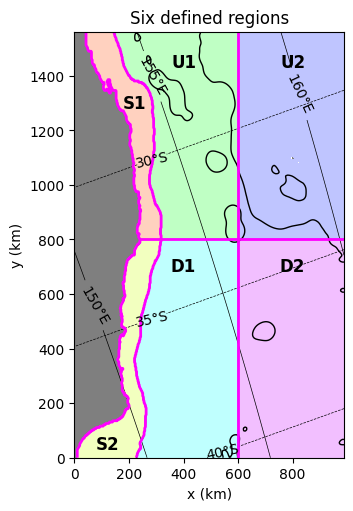

In [5]:
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

# left region, split into two by y = 800
bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

# outside region, left of x = 600, split by boundary of region_mask_grid
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

# right of x = 600, split by y = 800
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6


fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)

ax.contourf(X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
            levels=[0.5, 1.5], colors=['k'], alpha=.5)

ax.contourf(X_grid, Y_grid, bin_grid,
            levels=np.arange(0.5, 7.5, 1),
            alpha=0.25, cmap='gist_rainbow')

c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=levels_lat, colors='k', linewidths=.5)
ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')

c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=levels_lon, colors='k', linewidths=.5)
ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

ax.contour(X_grid, Y_grid, h, levels=[4000], colors='k', linewidths=1)
ax.contour(X_grid, Y_grid, region_mask_grid.astype(float),
           levels=[0.5], colors='magenta', linewidths=2)

ax.axvline(xsplit, color='magenta', lw=2)
# ax.axhline(ysplit, color='k', lw=1)
ax.plot([240, X_grid.max()], [ysplit, ysplit], 'magenta', lw=2)

ax.text(220, 1300, 'S1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(120, 50, 'S2', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(400, 1450, 'U1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(800, 1450, 'U2', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(400, 700, 'D1', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(800, 700, 'D2', ha='center', va='center', fontsize=12, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlim(X_grid.min(), X_grid.max())
ax.set_ylim(Y_grid.min(), Y_grid.max())
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('Six defined regions')

plt.show()


In [6]:
region_names = {
    1: 'S1',
    2: 'S2',
    3: 'U1',
    4: 'D1',
    5: 'U2',
    6: 'D2'
}

valid = np.isfinite(bin_grid)

tree = cKDTree(np.c_[X_grid[valid], Y_grid[valid]])

dist, idx = tree.query(df_eddies[['xc', 'yc']].to_numpy())

regions_num = bin_grid[valid][idx].astype(int)

df_eddies['region_num'] = regions_num
df_eddies['region'] = df_eddies['region_num'].map(region_names)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,AR,R,Age,Date,fname,TiltDis,TiltDir,norm_time,region_num,region
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,0.000000,5,U2
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,0.009434,5,U2
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,0.018868,5,U2
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976111,184.917110,0.028302,5,U2
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.065523,181.172847,0.037736,5,U2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,23.512541,69.098943,0.809524,6,D2
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,20.463430,69.913173,0.857143,6,D2
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,0.904762,6,D2
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,0.952381,6,D2


In [19]:
styles = {
    'AE': {'line': 'tab:red',  'fill': 'tab:red'},
    'CE': {'line': 'tab:blue', 'fill': 'tab:blue'}
}

def plot_region_panel(ax, df, xcol='norm_time', ycol='TiltDis', nbins=12, fit_percentiles=(10, 90)):
    
    df = df.dropna(subset=[xcol, ycol, 'Cyc']).copy()
    
    if len(df) < 5:
        return
    
    x_min, x_max = df[xcol].min(), df[xcol].max()
    bins = np.unique(np.quantile(df[xcol], np.linspace(0, 1, nbins + 1)))
    
    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, nbins + 1)
        
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    for cyc in ['AE', 'CE']:
        
        dfc = df[df.Cyc == cyc].dropna(subset=[xcol, ycol])
        
        if len(dfc) < 5:
            continue
        
        x = dfc[xcol].values
        y = dfc[ycol].values
        
        d = np.digitize(x, bins)
        
        med = np.array([
            np.nanmedian(y[d == i]) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        
        q25 = np.array([
            np.nanquantile(y[d == i], 0.25) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        
        q75 = np.array([
            np.nanquantile(y[d == i], 0.75) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        
        m = np.isfinite(med)
        
        ax.plot(bin_centers[m], med[m], lw=2.5, color=styles[cyc]['line'])#, label=f'{cyc} median')
        ax.fill_between(bin_centers[m], q25[m], q75[m], color=styles[cyc]['fill'], alpha=0.12)
        
        lo, hi = np.nanpercentile(x, fit_percentiles)
        fit_mask = (x >= lo) & (x <= hi)
        
        if fit_mask.sum() > 2:
            # mreg, c, r, p, se = linregress(x[fit_mask], y[fit_mask])
            mreg, c, r, p, se = linregress(x, y)
            # xf = np.linspace(lo, hi, 100)
            xf = np.linspace(0, 1, 100)
            ax.plot(
                xf, mreg * xf + c,
                '--', lw=2.5, color=styles[cyc]['fill'],
                label=fr'{cyc}: TD={mreg:.2f}t {c:+.2f}'
            )
        ax.set_xlim(0,1)
            

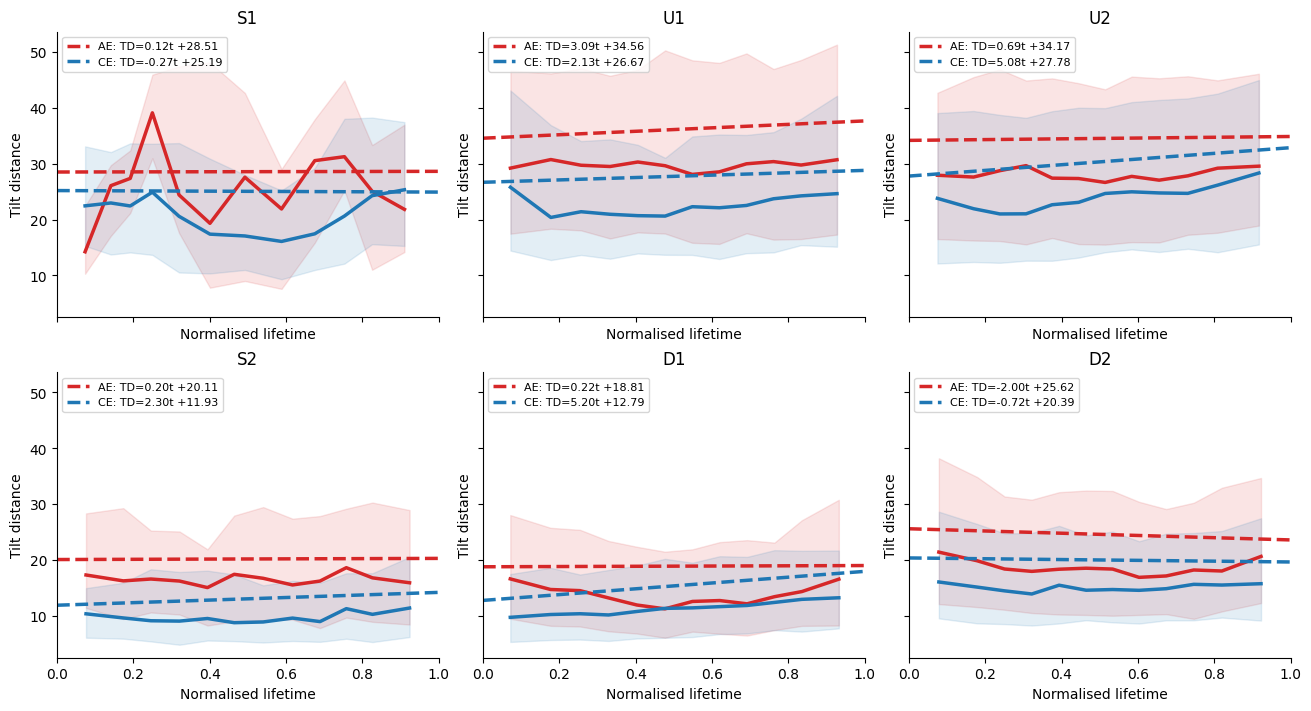

In [20]:
fig, axs = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True, constrained_layout=True)

ax_map = {
    'S1': axs[0, 0],
    'S2': axs[1, 0],
    'U1': axs[0, 1],
    'U2': axs[0, 2],
    'D1': axs[1, 1],
    'D2': axs[1, 2],
}

for region, ax in ax_map.items():
    
    df_region = df_eddies[df_eddies.region == region].copy()
    
    plot_region_panel(ax, df_region, xcol='norm_time', ycol='TiltDis', nbins=12)
    
    ax.set_title(region)
    ax.set_xlabel('Normalised lifetime')
    ax.set_ylabel('Tilt distance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, loc='upper left')

plt.show()


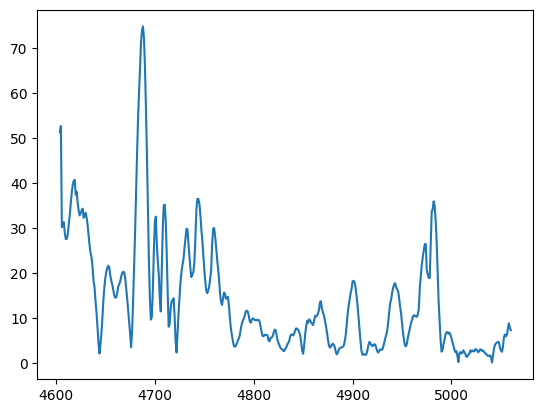

In [22]:
df_old_eddy = df_eddies[df_eddies.Age==df_eddies.Age.max()]
plt.plot(df_old_eddy.Day, df_old_eddy.TiltDis)


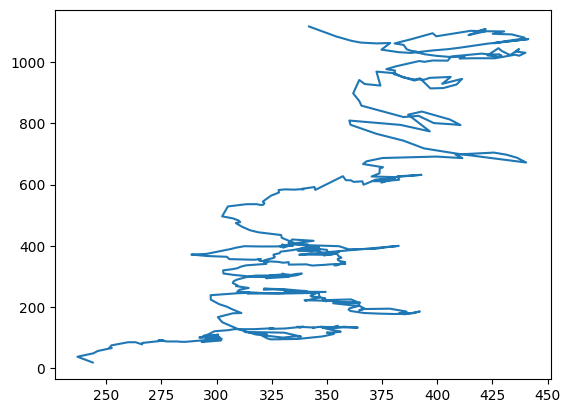

In [24]:
plt.plot(df_old_eddy.xc, df_old_eddy.yc)
